In [1]:
# =========================================================
# STORE SALES & PROFIT ANALYSIS
# FINAL OPTIMIZED PROFESSIONAL PIPELINE
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    OrdinalEncoder,
    StandardScaler
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)

from xgboost import XGBRegressor

import joblib


In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv(
    "superstore.csv",
    encoding='latin1'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# =========================================================
# 3. DISPLAY DATA
# =========================================================

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
print(df.info())


FIRST 5 ROWS
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

In [4]:
# =========================================================
# 4. CHECK MISSING VALUES
# =========================================================

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nTOTAL MISSING VALUES")
print(df.isnull().sum().sum())


MISSING VALUES
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

TOTAL MISSING VALUES
0


In [5]:
# =========================================================
# 5. REMOVE DUPLICATES
# =========================================================

print("\nDUPLICATE ROWS :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("SHAPE AFTER REMOVING DUPLICATES")
print(df.shape)


DUPLICATE ROWS : 0
SHAPE AFTER REMOVING DUPLICATES
(9994, 21)


In [6]:
# =========================================================
# 6. CONVERT DATE COLUMNS
# =========================================================

df['Order Date'] = pd.to_datetime(
    df['Order Date']
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date']
)

print("\nDATE CONVERSION COMPLETED")


DATE CONVERSION COMPLETED


In [7]:
# =========================================================
# 7. EXTRACT DATE FEATURES
# =========================================================

df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Day'] = df['Order Date'].dt.day

df['Quarter'] = df['Order Date'].dt.quarter

print("\nDATE FEATURES ADDED")


DATE FEATURES ADDED


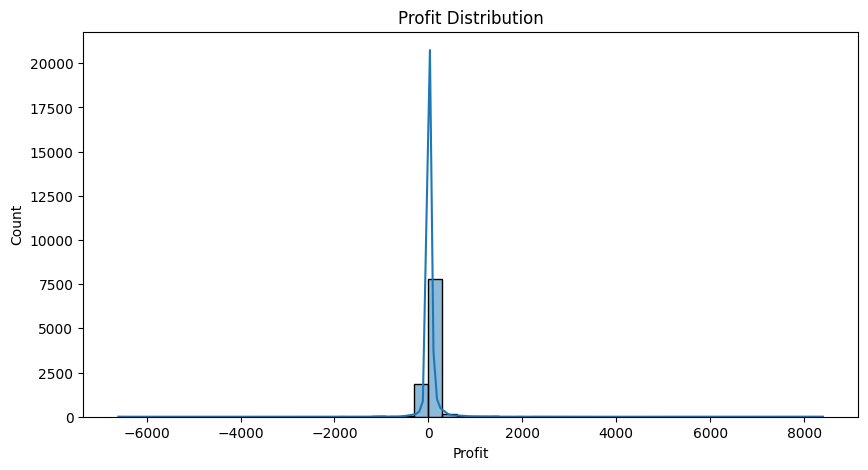

In [8]:
# =========================================================
# 8. CHECK TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['Profit'],
    kde=True,
    bins=50
)

plt.title("Profit Distribution")

plt.show()


In [9]:
# =========================================================
# 9. CHECK TARGET SKEWNESS
# =========================================================

print("\nPROFIT SKEWNESS")

print(df['Profit'].skew())

if df['Profit'].skew() > 1:

    print("Highly Right Skewed")

elif df['Profit'].skew() < -1:

    print("Highly Left Skewed")

else:

    print("Moderately Distributed")


PROFIT SKEWNESS
7.561431562468343
Highly Right Skewed


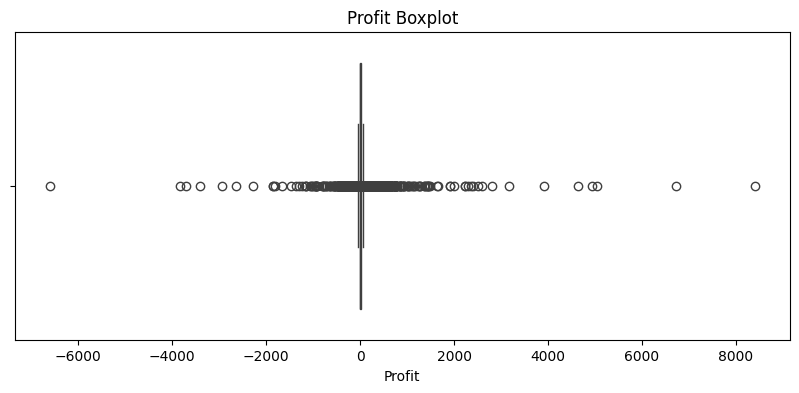

In [10]:
# =========================================================
# 10. CHECK OUTLIERS
# =========================================================

plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Profit']
)

plt.title("Profit Boxplot")

plt.show()

In [11]:
# =========================================================
# 11. HANDLE OUTLIERS USING IQR CAPPING
# =========================================================

def cap_outliers(col):

    Q1 = col.quantile(0.25)

    Q3 = col.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    return np.clip(col, lower, upper)


outlier_cols = [

    'Sales',

    'Profit',

    'Quantity',

    'Discount'
]

for col in outlier_cols:

    df[col] = cap_outliers(df[col])

print("\nOUTLIER CAPPING COMPLETED")


OUTLIER CAPPING COMPLETED


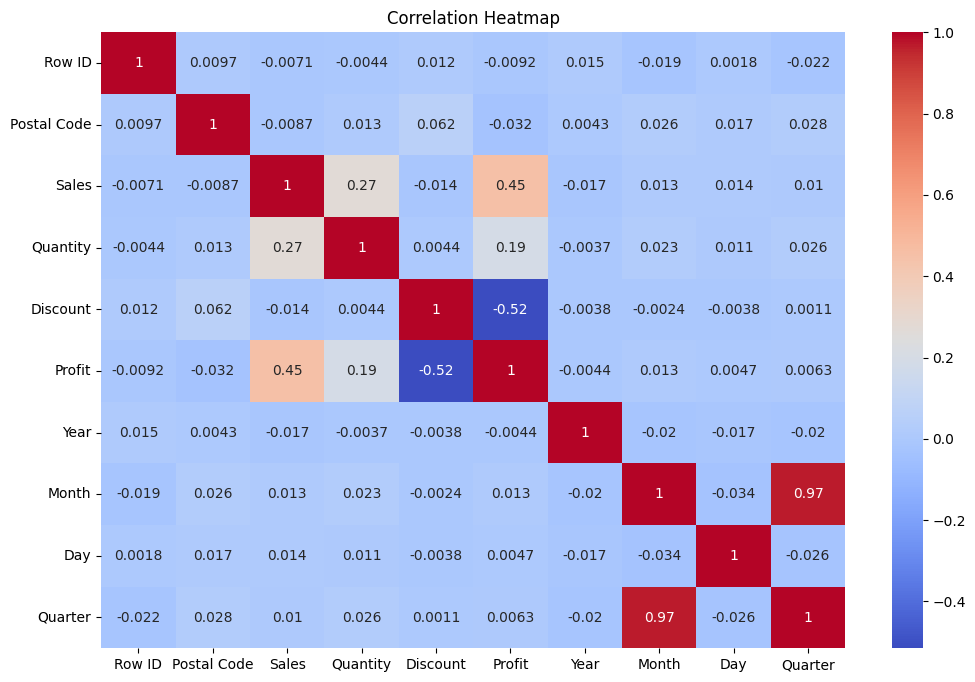

In [12]:
# =========================================================
# 12. CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

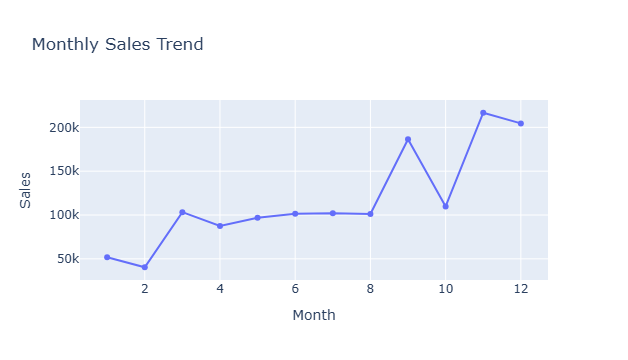

In [13]:
# =========================================================
# 13. SALES ANALYSIS
# =========================================================

# =========================================================
# MONTHLY SALES TREND
# =========================================================

monthly_sales = df.groupby(
    'Month'
)['Sales'].sum().reset_index()

fig = px.line(
    monthly_sales,
    x='Month',
    y='Sales',
    markers=True,
    title='Monthly Sales Trend'
)

fig.show()

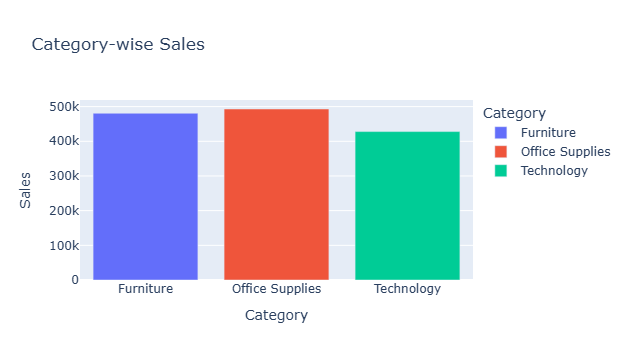

In [14]:
# =========================================================
# CATEGORY-WISE SALES
# =========================================================

category_sales = df.groupby(
    'Category'
)['Sales'].sum().reset_index()

fig = px.bar(
    category_sales,
    x='Category',
    y='Sales',
    color='Category',
    title='Category-wise Sales'
)

fig.show()

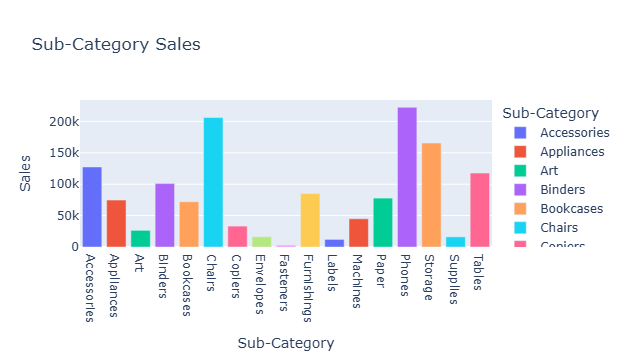

In [15]:
# =========================================================
# SUB-CATEGORY SALES
# =========================================================

subcat_sales = df.groupby(
    'Sub-Category'
)['Sales'].sum().reset_index()

fig = px.bar(
    subcat_sales,
    x='Sub-Category',
    y='Sales',
    color='Sub-Category',
    title='Sub-Category Sales'
)

fig.show()

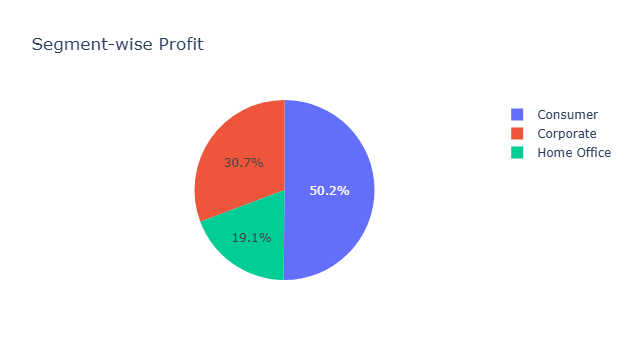

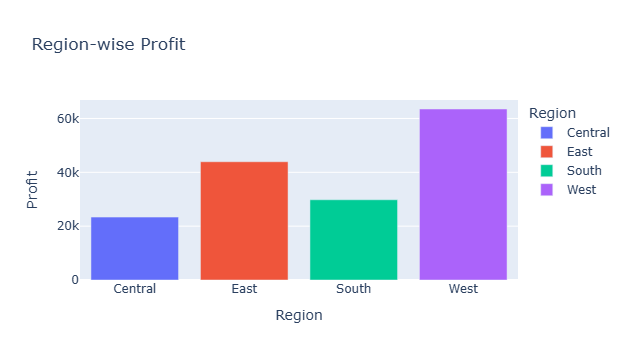

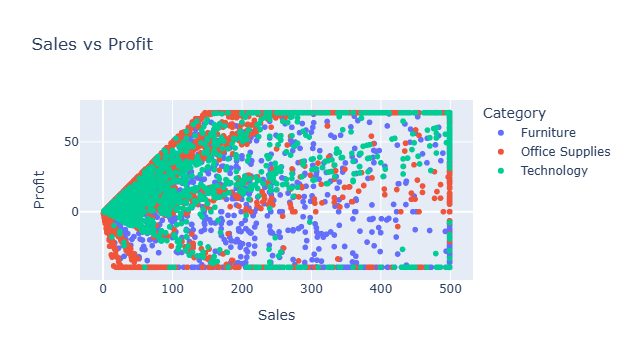

In [16]:
# =========================================================
# 14. PROFIT ANALYSIS
# =========================================================

# =========================================================
# SEGMENT-WISE PROFIT
# =========================================================

segment_profit = df.groupby(
    'Segment'
)['Profit'].sum().reset_index()

fig = px.pie(
    segment_profit,
    names='Segment',
    values='Profit',
    title='Segment-wise Profit'
)

fig.show()


# =========================================================
# REGION-WISE PROFIT
# =========================================================

region_profit = df.groupby(
    'Region'
)['Profit'].sum().reset_index()

fig = px.bar(
    region_profit,
    x='Region',
    y='Profit',
    color='Region',
    title='Region-wise Profit'
)

fig.show()


# =========================================================
# SALES VS PROFIT
# =========================================================

fig = px.scatter(
    df,
    x='Sales',
    y='Profit',
    color='Category',
    title='Sales vs Profit'
)

fig.show()

In [17]:
# =========================================================
# 15. KEEP FULL DATA FOR ANALYTICS
# =========================================================

analysis_df = df.copy()


# =========================================================
# 16. FINAL MODEL FEATURES
# =========================================================

model_features = [

    'Sales',

    'Discount',

    'Category',

    'Sub-Category',

    'State',

    'Quantity'
]

X = df[model_features]

y = df['Profit']

print("\nFINAL MODEL FEATURES")

print(X.columns)


FINAL MODEL FEATURES
Index(['Sales', 'Discount', 'Category', 'Sub-Category', 'State', 'Quantity'], dtype='object')


In [18]:
# =========================================================
# 17. CATEGORICAL & NUMERICAL COLUMNS
# =========================================================

cat_cols = [

    'Category',

    'Sub-Category',

    'State'
]

num_cols = [

    'Sales',

    'Discount',

    'Quantity'
]

print("\nCATEGORICAL COLUMNS")
print(cat_cols)

print("\nNUMERICAL COLUMNS")
print(num_cols)


CATEGORICAL COLUMNS
['Category', 'Sub-Category', 'State']

NUMERICAL COLUMNS
['Sales', 'Discount', 'Quantity']


In [19]:
# =========================================================
# 18. ENCODE CATEGORICAL FEATURES
# =========================================================

encoder = OrdinalEncoder()

X[cat_cols] = encoder.fit_transform(
    X[cat_cols]
)

print("\nENCODING COMPLETED")


ENCODING COMPLETED


In [20]:
# =========================================================
# 19. FEATURE IMPORTANCE
# =========================================================

rf_temp = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_temp.fit(X, y)

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_temp.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")

print(importance)


FEATURE IMPORTANCE
        Feature  Importance
0         Sales    0.436635
1      Discount    0.342945
3  Sub-Category    0.092482
2      Category    0.048494
5      Quantity    0.045058
4         State    0.034387


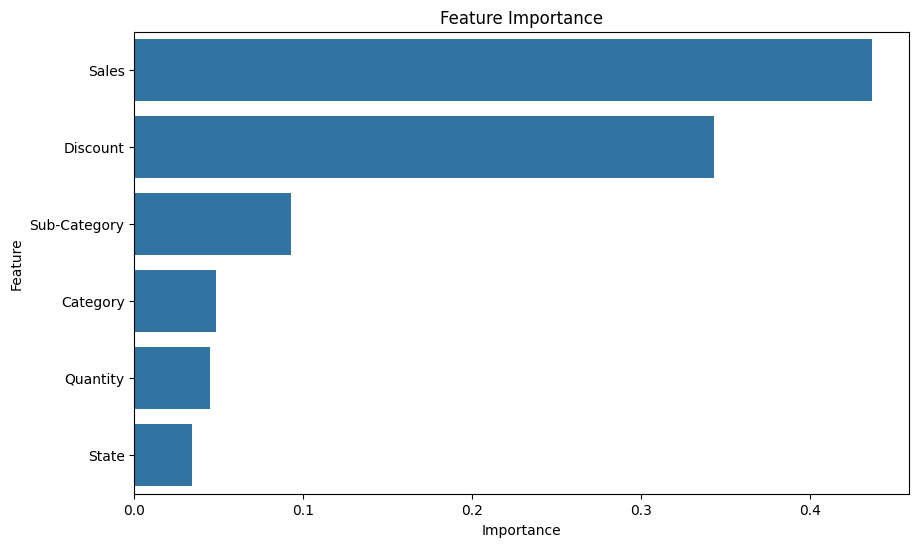

In [21]:
# =========================================================
# 20. FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [22]:
# =========================================================
# 21. FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
# =========================================================
# 22. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.2,

    random_state=42
)

print("\nTRAIN SHAPE :", X_train.shape)

print("TEST SHAPE :", X_test.shape)


TRAIN SHAPE : (7995, 6)
TEST SHAPE : (1999, 6)


In [24]:
# =========================================================
# 23. LINEAR REGRESSION
# =========================================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)

lr_test_pred = lr.predict(X_test)

In [25]:
# =========================================================
# 24. RANDOM FOREST
# =========================================================

rf = RandomForestRegressor(

    n_estimators=200,

    max_depth=10,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)

rf_test_pred = rf.predict(X_test)

In [26]:
# =========================================================
# 25. XGBOOST
# =========================================================

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.03,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=2,

    reg_lambda=3,

    min_child_weight=5,

    random_state=42
)

xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)

xgb_test_pred = xgb.predict(X_test)


In [27]:
# =========================================================
# 26. STACKING ENSEMBLE
# =========================================================

base_models = [

    ('rf', rf),

    ('xgb', xgb)
]

meta_model = Ridge()

stack_model = StackingRegressor(

    estimators=base_models,

    final_estimator=meta_model,

    cv=5
)

stack_model.fit(X_train, y_train)

stack_train_pred = stack_model.predict(X_train)

stack_test_pred = stack_model.predict(X_test)

In [28]:
# =========================================================
# 27. EVALUATION FUNCTION
# =========================================================

def evaluate_model(

    name,

    y_train,

    train_pred,

    y_test,

    test_pred
):

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    gap = abs(
        train_r2 - test_r2
    )

    print("\n", "="*60)

    print(name)

    print("="*60)

    print("Train R2 :", round(train_r2,4))

    print("Test R2 :", round(test_r2,4))

    print("Train RMSE :", round(train_rmse,4))

    print("Test RMSE :", round(test_rmse,4))

    print("Overfit Gap :", round(gap,4))

    if gap > 0.10:

        print("⚠ Overfitting Detected")

    else:

        print("✅ Model Balanced")

    return {

        'Model': name,

        'Train_R2': train_r2,

        'Test_R2': test_r2,

        'Train_RMSE': train_rmse,

        'Test_RMSE': test_rmse,

        'Gap': gap
    }

In [29]:
# =========================================================
# 28. EVALUATE MODELS
# =========================================================

results = []

results.append(

    evaluate_model(
        "Linear Regression",
        y_train,
        lr_train_pred,
        y_test,
        lr_test_pred
    )
)

results.append(

    evaluate_model(
        "Random Forest",
        y_train,
        rf_train_pred,
        y_test,
        rf_test_pred
    )
)

results.append(

    evaluate_model(
        "XGBoost",
        y_train,
        xgb_train_pred,
        y_test,
        xgb_test_pred
    )
)

results.append(

    evaluate_model(
        "Stacking Ensemble",
        y_train,
        stack_train_pred,
        y_test,
        stack_test_pred
    )
)


Linear Regression
Train R2 : 0.5016
Test R2 : 0.5007
Train RMSE : 20.9016
Test RMSE : 20.4845
Overfit Gap : 0.0009
✅ Model Balanced

Random Forest
Train R2 : 0.8953
Test R2 : 0.8315
Train RMSE : 9.581
Test RMSE : 11.8998
Overfit Gap : 0.0638
✅ Model Balanced

XGBoost
Train R2 : 0.8308
Test R2 : 0.8139
Train RMSE : 12.1789
Test RMSE : 12.5052
Overfit Gap : 0.0169
✅ Model Balanced

Stacking Ensemble
Train R2 : 0.8835
Test R2 : 0.8336
Train RMSE : 10.1044
Test RMSE : 11.8271
Overfit Gap : 0.05
✅ Model Balanced


In [30]:
# =========================================================
# 29. MODEL COMPARISON
# =========================================================

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Test_R2',
    ascending=False
)

print("\nFINAL MODEL COMPARISON")

print(comparison_df)


FINAL MODEL COMPARISON
               Model  Train_R2   Test_R2  Train_RMSE  Test_RMSE       Gap
3  Stacking Ensemble  0.883516  0.833559   10.104443  11.827116  0.049957
1      Random Forest  0.895272  0.831507    9.580982  11.899791  0.063765
2            XGBoost  0.830777  0.813926   12.178898  12.505199  0.016851
0  Linear Regression  0.501574  0.500709   20.901576  20.484496  0.000865


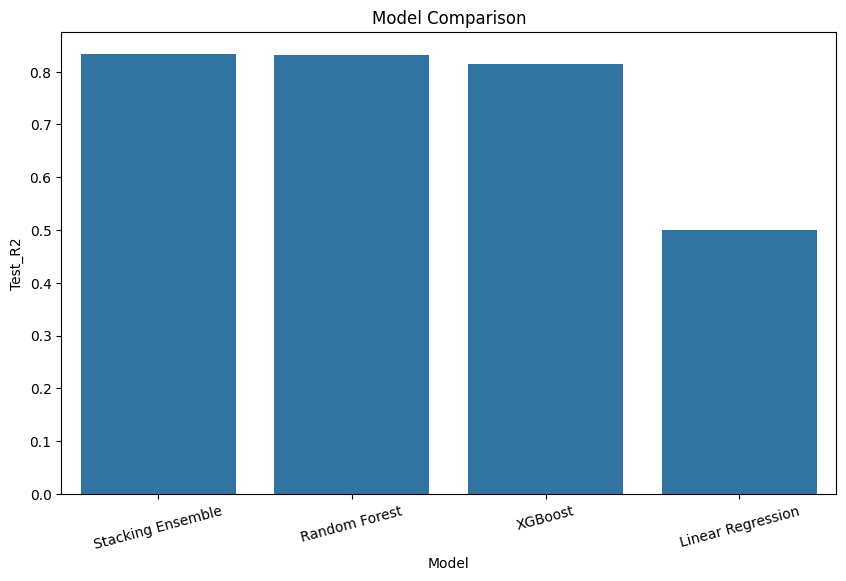

In [31]:
# =========================================================
# 30. MODEL COMPARISON PLOT
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Test_R2',
    data=comparison_df
)

plt.title("Model Comparison")

plt.xticks(rotation=15)

plt.show()

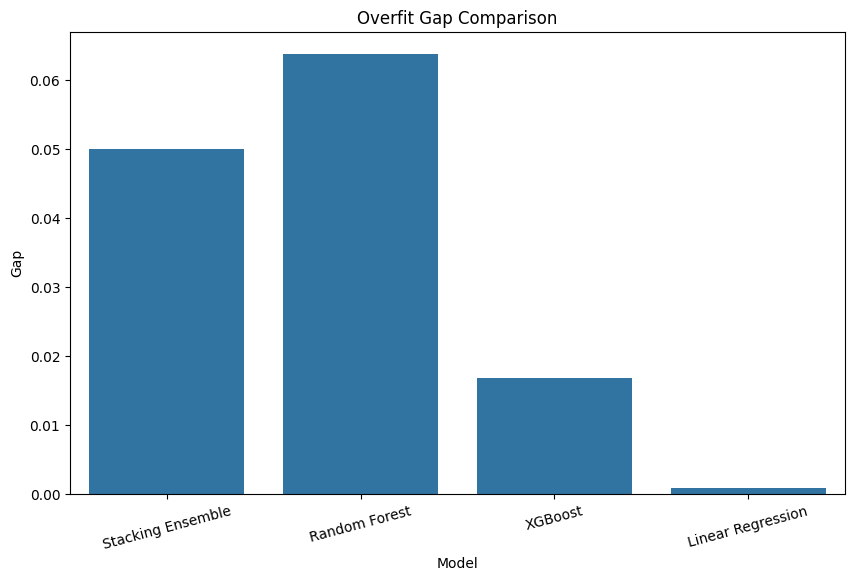

In [32]:
# =========================================================
# 31. OVERFIT GAP PLOT
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Gap',
    data=comparison_df
)

plt.title("Overfit Gap Comparison")

plt.xticks(rotation=15)

plt.show()

In [33]:
# =========================================================
# 32. BEST MODEL
# =========================================================

best_model = comparison_df.iloc[0]

print("\nBEST MODEL")

print(best_model)


BEST MODEL
Model         Stacking Ensemble
Train_R2               0.883516
Test_R2                0.833559
Train_RMSE            10.104443
Test_RMSE             11.827116
Gap                    0.049957
Name: 3, dtype: object


In [34]:
# =========================================================
# 33. SAVE FINAL FILES
# =========================================================

joblib.dump(
    stack_model,
    'final_stacking_model.pkl'
)

joblib.dump(
    scaler,
    'final_scaler.pkl'
)

joblib.dump(
    encoder,
    'final_encoder.pkl'
)

joblib.dump(
    X.columns.tolist(),
    'final_feature_columns.pkl'
)

print("\nFINAL MODEL FILES SAVED SUCCESSFULLY")


FINAL MODEL FILES SAVED SUCCESSFULLY


In [35]:
# =========================================================
# 34. LOAD MODEL
# =========================================================

loaded_model = joblib.load(
    'final_stacking_model.pkl'
)

print("\nMODEL LOADED SUCCESSFULLY")


MODEL LOADED SUCCESSFULLY


In [36]:
# =========================================================
# 35. SAMPLE PREDICTION
# =========================================================

sample = pd.DataFrame([{

    'Sales': 500,

    'Discount': 0.10,

    'Category': 'Furniture',

    'Sub-Category': 'Chairs',

    'State': 'California',

    'Quantity': 3
}])


sample[cat_cols] = encoder.transform(
    sample[cat_cols]
)

sample = sample[X.columns]

sample_scaled = scaler.transform(sample)

prediction = loaded_model.predict(
    sample_scaled
)

print("\nPREDICTED PROFIT :", round(prediction[0],2))


PREDICTED PROFIT : 66.15


In [37]:
# =========================================================
# 36. FINAL BUSINESS INSIGHTS
# =========================================================

print("\nFINAL BUSINESS INSIGHTS")

print("""

1. Discount is the strongest factor affecting profit.

2. Sales volume strongly influences profitability.

3. Product Category and Sub-Category are major profit drivers.

4. Some states generate better profit performance.

5. High sales do not always guarantee high profit.

6. Ensemble learning improved prediction performance.

7. Stacking Ensemble achieved the best balance between
   accuracy and generalization.

""")

print("\nPROJECT COMPLETED SUCCESSFULLY")


FINAL BUSINESS INSIGHTS


1. Discount is the strongest factor affecting profit.

2. Sales volume strongly influences profitability.

3. Product Category and Sub-Category are major profit drivers.

4. Some states generate better profit performance.

5. High sales do not always guarantee high profit.

6. Ensemble learning improved prediction performance.

7. Stacking Ensemble achieved the best balance between
   accuracy and generalization.



PROJECT COMPLETED SUCCESSFULLY


In [38]:
# =========================================================
# HYPERPARAMETER TUNING + FINAL OPTIMIZED PIPELINE
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

from sklearn.model_selection import (
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)

from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joblib


# =========================================================
# 2. RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================

rf_params = {

    'n_estimators': [100, 200, 300, 400],

    'max_depth': [6, 8, 10, 12, 15],

    'min_samples_split': [2, 5, 8, 10],

    'min_samples_leaf': [1, 2, 3, 4],

    'max_features': ['sqrt', 'log2']
}


rf_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_distributions=rf_params,

    n_iter=20,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=2,

    random_state=42
)


print("Tuning Random Forest...")

rf_search.fit(X_train, y_train)

print("\nBEST RANDOM FOREST PARAMETERS")

print(rf_search.best_params_)

Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

BEST RANDOM FOREST PARAMETERS
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}


In [39]:
# =========================================================
# 3. BEST RANDOM FOREST MODEL
# =========================================================

best_rf = rf_search.best_estimator_

rf_train_pred = best_rf.predict(X_train)

rf_test_pred = best_rf.predict(X_test)

In [40]:
# =========================================================
# 4. XGBOOST HYPERPARAMETER TUNING
# =========================================================

xgb_params = {

    'n_estimators': [100, 200, 300],

    'learning_rate': [0.01, 0.03, 0.05],

    'max_depth': [3, 4, 5, 6],

    'subsample': [0.7, 0.8, 1.0],

    'colsample_bytree': [0.7, 0.8, 1.0],

    'min_child_weight': [1, 3, 5],

    'reg_alpha': [0, 1, 2],

    'reg_lambda': [1, 2, 3]
}


xgb_search = RandomizedSearchCV(

    estimator=XGBRegressor(
        random_state=42
    ),

    param_distributions=xgb_params,

    n_iter=20,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=2,

    random_state=42
)


print("\nTuning XGBoost...")

xgb_search.fit(X_train, y_train)

print("\nBEST XGBOOST PARAMETERS")

print(xgb_search.best_params_)


# =========================================================
# 5. BEST XGBOOST MODEL
# =========================================================

best_xgb = xgb_search.best_estimator_

xgb_train_pred = best_xgb.predict(X_train)

xgb_test_pred = best_xgb.predict(X_test)



Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

BEST XGBOOST PARAMETERS
{'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [41]:
# =========================================================
# 6. STACKING ENSEMBLE WITH TUNED MODELS
# =========================================================

base_models = [

    ('rf', best_rf),

    ('xgb', best_xgb)
]

meta_model = Ridge()

stack_model = StackingRegressor(

    estimators=base_models,

    final_estimator=meta_model,

    cv=5,

    n_jobs=-1
)


print("\nTraining Stacking Ensemble...")

stack_model.fit(X_train, y_train)

stack_train_pred = stack_model.predict(X_train)

stack_test_pred = stack_model.predict(X_test)



Training Stacking Ensemble...


In [42]:
# =========================================================
# 7. EVALUATION FUNCTION
# =========================================================

def evaluate_model(

    name,

    y_train,

    train_pred,

    y_test,

    test_pred
):

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    gap = abs(
        train_r2 - test_r2
    )

    print("\n", "="*60)

    print(name)

    print("="*60)

    print("Train R2 :", round(train_r2,4))

    print("Test R2  :", round(test_r2,4))

    print("Train RMSE :", round(train_rmse,4))

    print("Test RMSE  :", round(test_rmse,4))

    print("Overfit Gap :", round(gap,4))

    if gap > 0.10:

        print("⚠️ Overfitting Detected")

    else:

        print("✅ Model Balanced")

    return {

        'Model': name,

        'Train_R2': train_r2,

        'Test_R2': test_r2,

        'Train_RMSE': train_rmse,

        'Test_RMSE': test_rmse,

        'Gap': gap
    }


In [43]:
# =========================================================
# 8. EVALUATE TUNED MODELS
# =========================================================

results = []


results.append(

    evaluate_model(
        "Tuned Random Forest",
        y_train,
        rf_train_pred,
        y_test,
        rf_test_pred
    )
)


results.append(

    evaluate_model(
        "Tuned XGBoost",
        y_train,
        xgb_train_pred,
        y_test,
        xgb_test_pred
    )
)


results.append(

    evaluate_model(
        "Tuned Stacking Ensemble",
        y_train,
        stack_train_pred,
        y_test,
        stack_test_pred
    )
)


# =========================================================
# 9. FINAL COMPARISON TABLE
# =========================================================

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Test_R2',
    ascending=False
)

print("\nFINAL MODEL COMPARISON")

print(comparison_df)



Tuned Random Forest
Train R2 : 0.9053
Test R2  : 0.831
Train RMSE : 9.1087
Test RMSE  : 11.9193
Overfit Gap : 0.0744
✅ Model Balanced

Tuned XGBoost
Train R2 : 0.8858
Test R2  : 0.8373
Train RMSE : 10.0053
Test RMSE  : 11.694
Overfit Gap : 0.0485
✅ Model Balanced

Tuned Stacking Ensemble
Train R2 : 0.9012
Test R2  : 0.8371
Train RMSE : 9.3044
Test RMSE  : 11.7018
Overfit Gap : 0.0642
✅ Model Balanced

FINAL MODEL COMPARISON
                     Model  Train_R2   Test_R2  Train_RMSE  Test_RMSE  \
1            Tuned XGBoost  0.885791  0.837284   10.005281  11.694020   
2  Tuned Stacking Ensemble  0.901230  0.837066    9.304435  11.701833   
0      Tuned Random Forest  0.905342  0.830954    9.108721  11.919291   

        Gap  
1  0.048507  
2  0.064164  
0  0.074388  


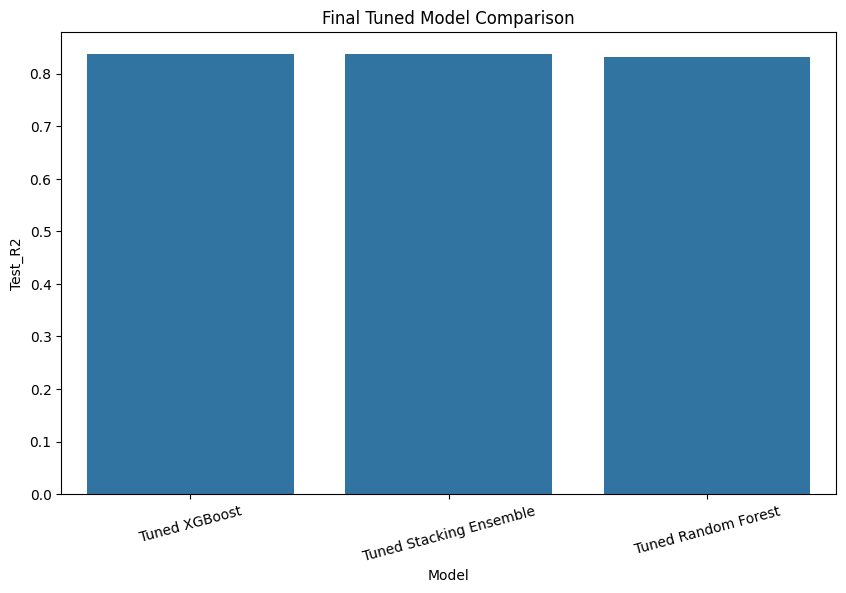

In [44]:
# =========================================================
# 10. VISUALIZE MODEL PERFORMANCE
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Test_R2',
    data=comparison_df
)

plt.title("Final Tuned Model Comparison")

plt.xticks(rotation=15)

plt.show()

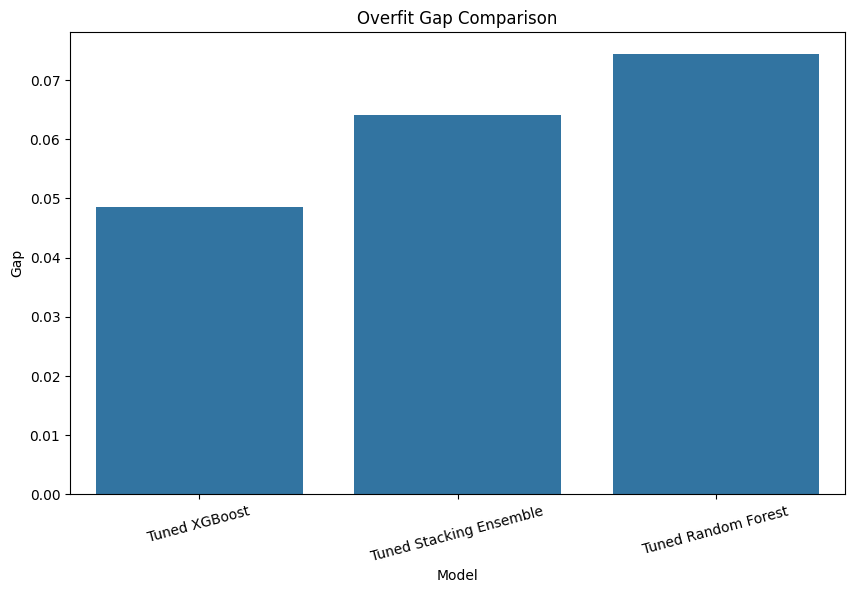

In [45]:
# =========================================================
# 11. OVERFIT GAP VISUALIZATION
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Gap',
    data=comparison_df
)

plt.title("Overfit Gap Comparison")

plt.xticks(rotation=15)

plt.show()


In [46]:
# =========================================================
# 12. CROSS VALIDATION
# =========================================================

print("\nPerforming Cross Validation...")

cv_scores = cross_val_score(

    stack_model,

    X_scaled,

    y,

    cv=5,

    scoring='r2'
)

print("\nCross Validation Scores")

print(cv_scores)

print("\nAverage CV Score")

print(cv_scores.mean())



Performing Cross Validation...

Cross Validation Scores
[0.81416704 0.8114405  0.83954754 0.85443976 0.83558312]

Average CV Score
0.8310355905485375


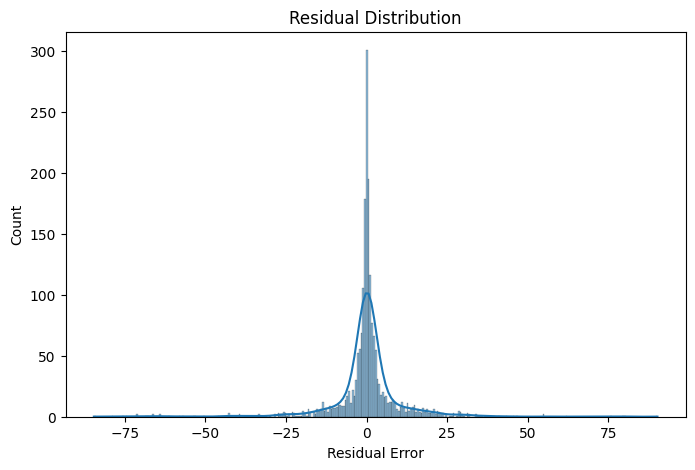

In [47]:
# =========================================================
# 13. RESIDUAL ANALYSIS
# =========================================================

residuals = y_test - stack_test_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

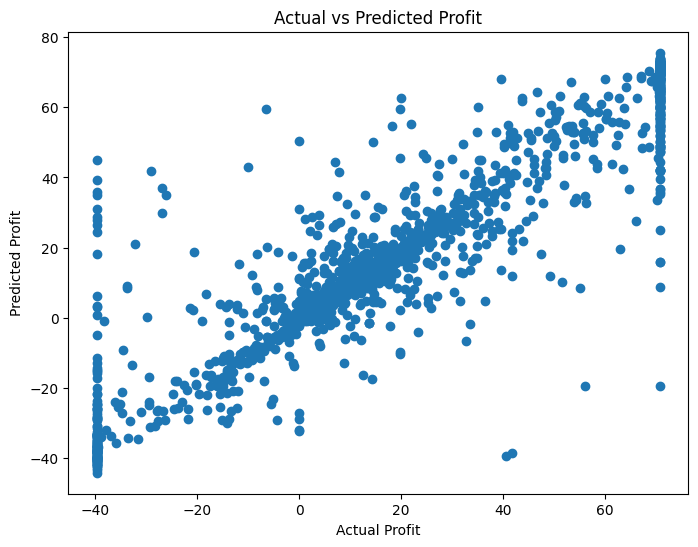

In [48]:
# =========================================================
# 14. ACTUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    stack_test_pred
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()


In [49]:
# =========================================================
# 15. BEST MODEL
# =========================================================

best_model = comparison_df.iloc[0]

print("\nBEST MODEL")

print(best_model)


BEST MODEL
Model         Tuned XGBoost
Train_R2           0.885791
Test_R2            0.837284
Train_RMSE        10.005281
Test_RMSE          11.69402
Gap                0.048507
Name: 1, dtype: object


In [52]:
# =========================================================
# SAVE FINAL BEST MODEL FILES
# =========================================================

import os
import joblib

# Create folder
os.makedirs(
    'best_model',
    exist_ok=True
)

# Save BEST MODEL (Tuned XGBoost)
joblib.dump(
    best_xgb,
    'best_model/final_xgboost_model.pkl'
)

# Save scaler
joblib.dump(
    scaler,
    'best_model/final_scaler.pkl'
)

# Save encoder
joblib.dump(
    encoder,
    'best_model/final_encoder.pkl'
)

# Save feature columns
joblib.dump(
    X.columns.tolist(),
    'best_model/final_feature_columns.pkl'
)

print("\nFINAL BEST MODEL FILES SAVED SUCCESSFULLY")


FINAL BEST MODEL FILES SAVED SUCCESSFULLY


In [51]:
# =========================================================
# 17. SAMPLE PREDICTION
# =========================================================

sample = pd.DataFrame([{

    'Sales': 500,

    'Discount': 0.10,

    'Category': 'Furniture',

    'Sub-Category': 'Chairs',

    'State': 'California',

    'Quantity': 3
}])


sample[cat_cols] = encoder.transform(
    sample[cat_cols]
)

sample = sample[X.columns]

sample_scaled = scaler.transform(sample)

prediction = stack_model.predict(
    sample_scaled
)

print("\nPREDICTED PROFIT :", round(prediction[0],2))


PREDICTED PROFIT : 65.1
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=200; total time=   1.4s
[CV] END max_depth=8, max_features=sqrt, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=   1.9s
[CV] END max_depth=6, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time=   2.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=5, n_estimators=200; total time=   1.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   1.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=3, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=5, n_estima